<a href="https://colab.research.google.com/github/poojya100/6thSem-ML-Lab/blob/main/1BM23CS303_Lab_9_Kmeans_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KMeans Clustering

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


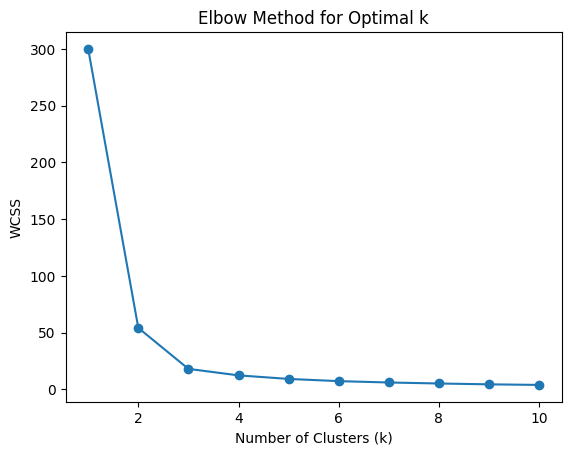

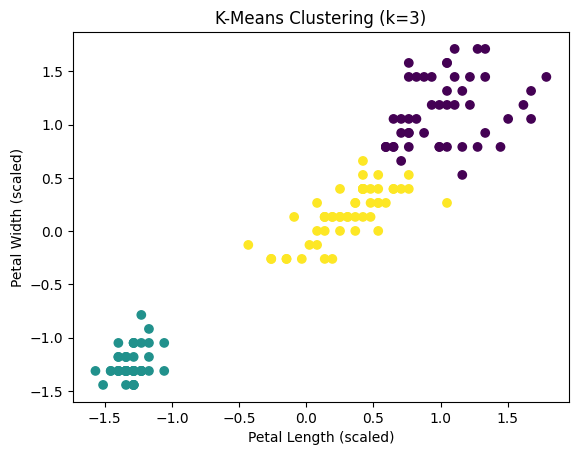

   sepal_length  sepal_width  petal_length  petal_width      species  cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        1
2           4.7          3.2           1.3          0.2  Iris-setosa        1
3           4.6          3.1           1.5          0.2  Iris-setosa        1
4           5.0          3.6           1.4          0.2  Iris-setosa        1


In [1]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# LOAD DATASET
df = pd.read_csv("iris (1).csv")

# DISPLAY FIRST FEW ROWS
print(df.head())

# SELECT FEATURES (Petal Length & Petal Width)
# Make sure column names match your dataset exactly
X = df[['petal_length', 'petal_width']]

# -------------------------------
# STEP 1: PREPROCESSING (SCALING)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# STEP 2: ELBOW METHOD
# -------------------------------
wcss = []  # Within-cluster sum of squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# PLOT ELBOW GRAPH
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()

# -------------------------------
# STEP 3: APPLY K-MEANS
# -------------------------------
# From elbow plot, usually k = 3 for IRIS
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# ADD CLUSTER LABELS TO DATAFRAME
df['cluster'] = y_pred

# -------------------------------
# STEP 4: VISUALIZE CLUSTERS
# -------------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred)
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering (k=3)")
plt.show()

# PRINT FINAL DATA
print(df.head())